# Figure app of GLOBECOM2026

## const_size graph

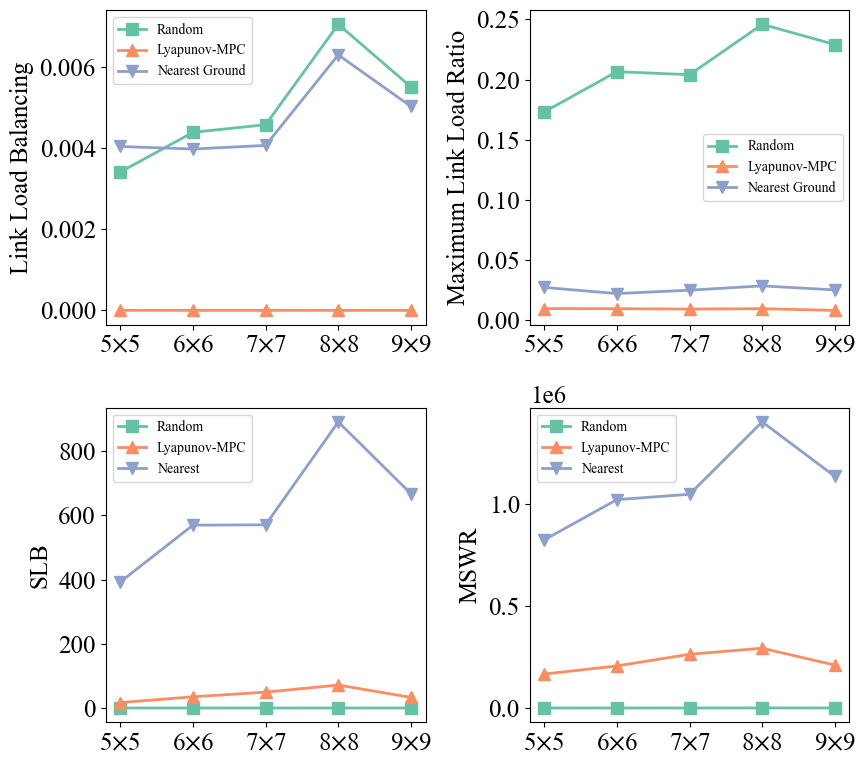

In [1]:
import json

lyap_MPC = json.load(
    open(r"lyap_MPC_record_const_size.json", "r")
)
nearest_gnd = json.load(
    open(
        r"nearest_gnd_record_const_size.json",
        "r",
    )
)
nearest = json.load(
    open(r"nearest_record_const_size.json", "r")
)
rand = json.load(
    open(r"rand_record_const_size.json", "r")
)

# * obtain data
last_id = 10086
const_list = []
len_list = []
mean_value_const_size = []  # lyap_MPC, nearest_gnd, nearest, rand

for idx, item in enumerate(lyap_MPC):
    if item["const_size"] != last_id:
        last_id = item["const_size"]
        const_list.append(item["const_size"])
        len_list.append(1)
        mean_value_const_size.append([{}, {}, {}, {}])

        # * LLR
        mean_value_const_size[-1][0]["link_load_ratio"] = item["link_load_ratio"]
        mean_value_const_size[-1][1]["link_load_ratio"] = nearest_gnd[idx][
            "link_load_ratio"
        ]
        mean_value_const_size[-1][3]["link_load_ratio"] = rand[idx]["link_load_ratio"]

        # * SPR
        mean_value_const_size[-1][0]["sat_pload_ratio"] = item["sat_pload_ratio"]
        mean_value_const_size[-1][2]["sat_pload_ratio"] = nearest[idx][
            "sat_pload_ratio"
        ]
        mean_value_const_size[-1][3]["sat_pload_ratio"] = rand[idx]["sat_pload_ratio"]

        # * MLLR
        mean_value_const_size[-1][0]["max_link_load_ratio"] = item[
            "max_link_load_ratio"
        ]
        mean_value_const_size[-1][1]["max_link_load_ratio"] = nearest_gnd[idx][
            "max_link_load_ratio"
        ]
        mean_value_const_size[-1][3]["max_link_load_ratio"] = rand[idx][
            "max_link_load_ratio"
        ]

        # * MSP
        mean_value_const_size[-1][0]["max_sat_pload"] = item["max_sat_pload"]
        mean_value_const_size[-1][2]["max_sat_pload"] = nearest[idx]["max_sat_pload"]
        mean_value_const_size[-1][3]["max_sat_pload"] = rand[idx]["max_sat_pload"]
    else:
        len_list[-1] += 1
        # * LLR
        mean_value_const_size[-1][0]["link_load_ratio"] += item["link_load_ratio"]
        mean_value_const_size[-1][1]["link_load_ratio"] += nearest_gnd[idx][
            "link_load_ratio"
        ]
        mean_value_const_size[-1][3]["link_load_ratio"] += rand[idx]["link_load_ratio"]

        # * SPR
        mean_value_const_size[-1][0]["sat_pload_ratio"] += item["sat_pload_ratio"]
        mean_value_const_size[-1][2]["sat_pload_ratio"] += nearest[idx][
            "sat_pload_ratio"
        ]
        mean_value_const_size[-1][3]["sat_pload_ratio"] += rand[idx]["sat_pload_ratio"]

        # * MLLR
        mean_value_const_size[-1][0]["max_link_load_ratio"] += item[
            "max_link_load_ratio"
        ]
        mean_value_const_size[-1][1]["max_link_load_ratio"] += nearest_gnd[idx][
            "max_link_load_ratio"
        ]
        mean_value_const_size[-1][3]["max_link_load_ratio"] += rand[idx][
            "max_link_load_ratio"
        ]

        # * MSP
        mean_value_const_size[-1][0]["max_sat_pload"] += item["max_sat_pload"]
        mean_value_const_size[-1][2]["max_sat_pload"] += nearest[idx]["max_sat_pload"]
        mean_value_const_size[-1][3]["max_sat_pload"] += rand[idx]["max_sat_pload"]

for idx, length in enumerate(len_list):
    for j in range(4):
        if "link_load_ratio" in mean_value_const_size[idx][j]:
            mean_value_const_size[idx][j]["link_load_ratio"] /= length
        if "sat_pload_ratio" in mean_value_const_size[idx][j]:
            mean_value_const_size[idx][j]["sat_pload_ratio"] /= length
        if "max_link_load_ratio" in mean_value_const_size[idx][j]:
            mean_value_const_size[idx][j]["max_link_load_ratio"] /= length
        if "max_sat_pload" in mean_value_const_size[idx][j]:
            mean_value_const_size[idx][j]["max_sat_pload"] /= length

# * draw 4 subplots, with x-axis: const_list, y-axis: 4 keys in mean_value_const_size
import matplotlib.pyplot as plt

plt.rcParams.update(
    {
        "font.size": 18,
        "legend.fontsize": 10,
        "lines.linewidth": 2,
        "font.family": "serif",
        "font.serif": ["Times New Roman"],
        "mathtext.fontset": "stix",  # makes math text match Times
        "axes.prop_cycle": plt.cycler(color=plt.cm.Set2.colors),
    }
)

marker_size = 8
metric_list = [
    "Link Load Balancing",    
    "Maximum Link Load Ratio",
    "SLB",
    "MSWR",
]
# subplot_name = ["a", "b", "c", "d"]

fig, axs = plt.subplots(2, 2, figsize=(9, 8))
for idx, key in enumerate(
    ["link_load_ratio", "max_link_load_ratio", "sat_pload_ratio", "max_sat_pload"]
):
    x = [rf"{i}$\times${i}" for i in const_list]
    y1 = [item[0][key] for item in mean_value_const_size]
    y4 = [item[3][key] for item in mean_value_const_size]

    ax = axs[idx // 2, idx % 2]
    ax.plot(x, y4, label="Random", marker="s", markersize=marker_size)
    ax.plot(x, y1, label="Lyapunov-MPC", marker="^", markersize=marker_size)

    if idx == 0 or idx == 1:
        y2 = [item[1][key] for item in mean_value_const_size]
        ax.plot(x, y2, label="Nearest Ground", marker="v", markersize=marker_size)
    else:
        y3 = [item[2][key] for item in mean_value_const_size]
        ax.plot(x, y3, label="Nearest", marker="v", markersize=marker_size)

    # ax.set_xlabel(f"({subplot_name[idx]})")
    # ax.set_xlabel('Walker Delta Constellation Size')
    ax.set_ylabel(metric_list[idx])
    # ax.set_title(f'{key} vs const_size')
    ax.legend()

# fig.text(0.5, 0.01, "Walker Delta Constellation Size", ha="center")
plt.tight_layout()
fig.savefig("const_size.pdf", bbox_inches="tight")
plt.show()

## task_num graph

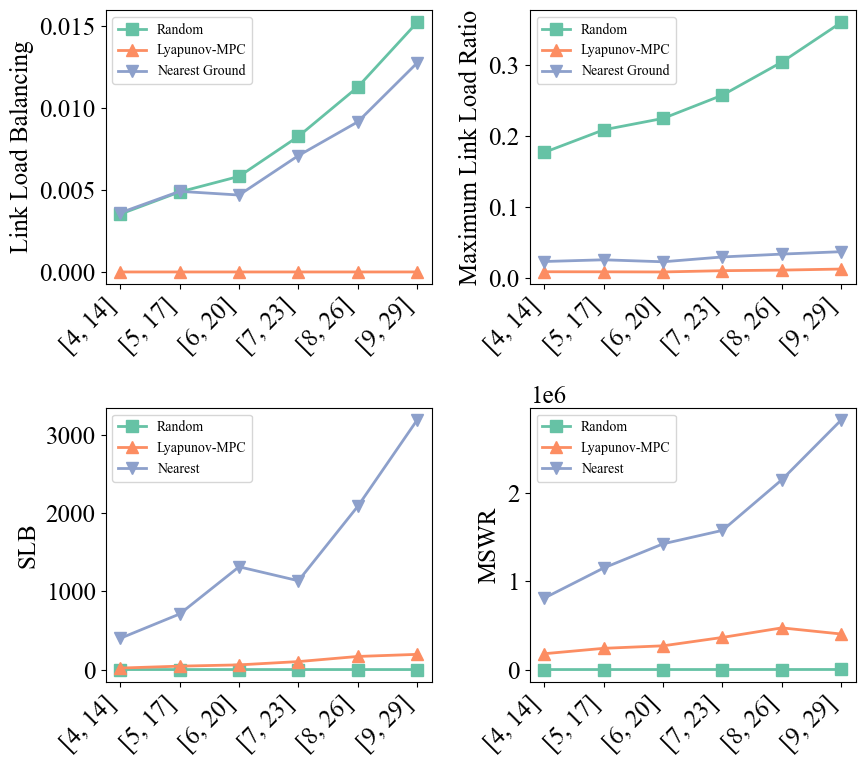

In [2]:
lyap_MPC = json.load(
    open(r"lyap_MPC_record_task_num.json", "r")
)
nearest_gnd = json.load(
    open(
        r"nearest_gnd_record_task_num.json", "r"
    )
)
nearest = json.load(
    open(r"nearest_record_task_num.json", "r")
)
rand = json.load(
    open(r"rand_record_task_num.json", "r")
)

# * obtain data
last_task_num = []
task_num_list = []
len_list = []
mean_value_task = []  # lyap_MPC, nearest_gnd, nearest, rand

for idx, item in enumerate(lyap_MPC):
    if item["mean_task_num"] != last_task_num:
        last_task_num = item["mean_task_num"]
        task_num_list.append(item["mean_task_num"])
        len_list.append(1)
        mean_value_task.append([{}, {}, {}, {}])

        # * LLR
        mean_value_task[-1][0]["link_load_ratio"] = item["link_load_ratio"]
        mean_value_task[-1][1]["link_load_ratio"] = nearest_gnd[idx]["link_load_ratio"]
        mean_value_task[-1][3]["link_load_ratio"] = rand[idx]["link_load_ratio"]

        # * SPR
        mean_value_task[-1][0]["sat_pload_ratio"] = item["sat_pload_ratio"]
        mean_value_task[-1][2]["sat_pload_ratio"] = nearest[idx]["sat_pload_ratio"]
        mean_value_task[-1][3]["sat_pload_ratio"] = rand[idx]["sat_pload_ratio"]

        # * MLLR
        mean_value_task[-1][0]["max_link_load_ratio"] = item["max_link_load_ratio"]
        mean_value_task[-1][1]["max_link_load_ratio"] = nearest_gnd[idx][
            "max_link_load_ratio"
        ]
        mean_value_task[-1][3]["max_link_load_ratio"] = rand[idx]["max_link_load_ratio"]

        # * MSP
        mean_value_task[-1][0]["max_sat_pload"] = item["max_sat_pload"]
        mean_value_task[-1][2]["max_sat_pload"] = nearest[idx]["max_sat_pload"]
        mean_value_task[-1][3]["max_sat_pload"] = rand[idx]["max_sat_pload"]
    else:
        len_list[-1] += 1
        # * LLR
        mean_value_task[-1][0]["link_load_ratio"] += item["link_load_ratio"]
        mean_value_task[-1][1]["link_load_ratio"] += nearest_gnd[idx]["link_load_ratio"]
        mean_value_task[-1][3]["link_load_ratio"] += rand[idx]["link_load_ratio"]

        # * SPR
        mean_value_task[-1][0]["sat_pload_ratio"] += item["sat_pload_ratio"]
        mean_value_task[-1][2]["sat_pload_ratio"] += nearest[idx]["sat_pload_ratio"]
        mean_value_task[-1][3]["sat_pload_ratio"] += rand[idx]["sat_pload_ratio"]

        # * MLLR
        mean_value_task[-1][0]["max_link_load_ratio"] += item["max_link_load_ratio"]
        mean_value_task[-1][1]["max_link_load_ratio"] += nearest_gnd[idx][
            "max_link_load_ratio"
        ]
        mean_value_task[-1][3]["max_link_load_ratio"] += rand[idx][
            "max_link_load_ratio"
        ]

        # * MSP
        mean_value_task[-1][0]["max_sat_pload"] += item["max_sat_pload"]
        mean_value_task[-1][2]["max_sat_pload"] += nearest[idx]["max_sat_pload"]
        mean_value_task[-1][3]["max_sat_pload"] += rand[idx]["max_sat_pload"]

for idx, length in enumerate(len_list):
    for j in range(4):
        if "link_load_ratio" in mean_value_task[idx][j]:
            mean_value_task[idx][j]["link_load_ratio"] /= length
        if "sat_pload_ratio" in mean_value_task[idx][j]:
            mean_value_task[idx][j]["sat_pload_ratio"] /= length
        if "max_link_load_ratio" in mean_value_task[idx][j]:
            mean_value_task[idx][j]["max_link_load_ratio"] /= length
        if "max_sat_pload" in mean_value_task[idx][j]:
            mean_value_task[idx][j]["max_sat_pload"] /= length

# * draw 4 subplots, with x-axis: const_list, y-axis: 4 keys in mean_value_task
import numpy as np

l = len(task_num_list)
new_mean_value_task = []
new_task_num_list = []
for i in range(l):
    if i % 2:
        new_mean_value_task.append(mean_value_task[i])
        new_task_num_list.append(task_num_list[i])

mean_value_task = new_mean_value_task
task_num_list = new_task_num_list

fig, axs = plt.subplots(2, 2, figsize=(9, 8))
for idx, key in enumerate(
    ["link_load_ratio", "max_link_load_ratio", "sat_pload_ratio", "max_sat_pload"]
):
    x = [f"[{int(i/2)}, {int(np.ceil(i*1.5))}]" for i in task_num_list]
    y1 = [item[0][key] for item in mean_value_task]
    y4 = [item[3][key] for item in mean_value_task]

    ax = axs[idx // 2, idx % 2]
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    ax.plot(x, y4, label="Random", marker="s", markersize=marker_size)
    ax.plot(x, y1, label="Lyapunov-MPC", marker="^", markersize=marker_size)

    if idx == 0 or idx == 1:
        y2 = [item[1][key] for item in mean_value_task]
        ax.plot(x, y2, label="Nearest Ground", marker="v", markersize=marker_size)
    else:
        y3 = [item[2][key] for item in mean_value_task]
        ax.plot(x, y3, label="Nearest", marker="v", markersize=marker_size)

    # ax.set_xlabel(f"({subplot_name[idx]})")
    # ax.set_xlabel('Walker Delta Constellation Size')
    ax.set_ylabel(metric_list[idx])
    # ax.set_title(f'{key} vs const_size')
    ax.legend()

# fig.text(0.5, 0.01, "Walker Delta Constellation Size", ha="center")
plt.tight_layout()
fig.savefig("task_num.pdf", bbox_inches="tight")
plt.show()

## V_test graph

mean_value_V [[{'offload_cost': 81.8, 'link_load_ratio': 1.8183673469387757e-06, 'sat_pload_ratio': 82.71080254463058, 'max_link_load_ratio': 0.0085, 'max_sat_pload': 290772.0524112441}], [{'offload_cost': 1162197181.761141, 'link_load_ratio': 2.5346938775510205e-06, 'sat_pload_ratio': 37.1473455354275, 'max_link_load_ratio': 0.008700000000000003, 'max_sat_pload': 247317.26236056382}], [{'offload_cost': 608161647.2233298, 'link_load_ratio': 2.4153061224489795e-06, 'sat_pload_ratio': 50.637679367668376, 'max_link_load_ratio': 0.008800000000000002, 'max_sat_pload': 255912.54304003896}], [{'offload_cost': 561088826.9734981, 'link_load_ratio': 2.595918367346939e-06, 'sat_pload_ratio': 44.27028011994518, 'max_link_load_ratio': 0.008800000000000002, 'max_sat_pload': 261261.24411168616}], [{'offload_cost': 553754613.146323, 'link_load_ratio': 2.4653061224489795e-06, 'sat_pload_ratio': 49.345461286483115, 'max_link_load_ratio': 0.008300000000000002, 'max_sat_pload': 276350.65268329025}], [{'of

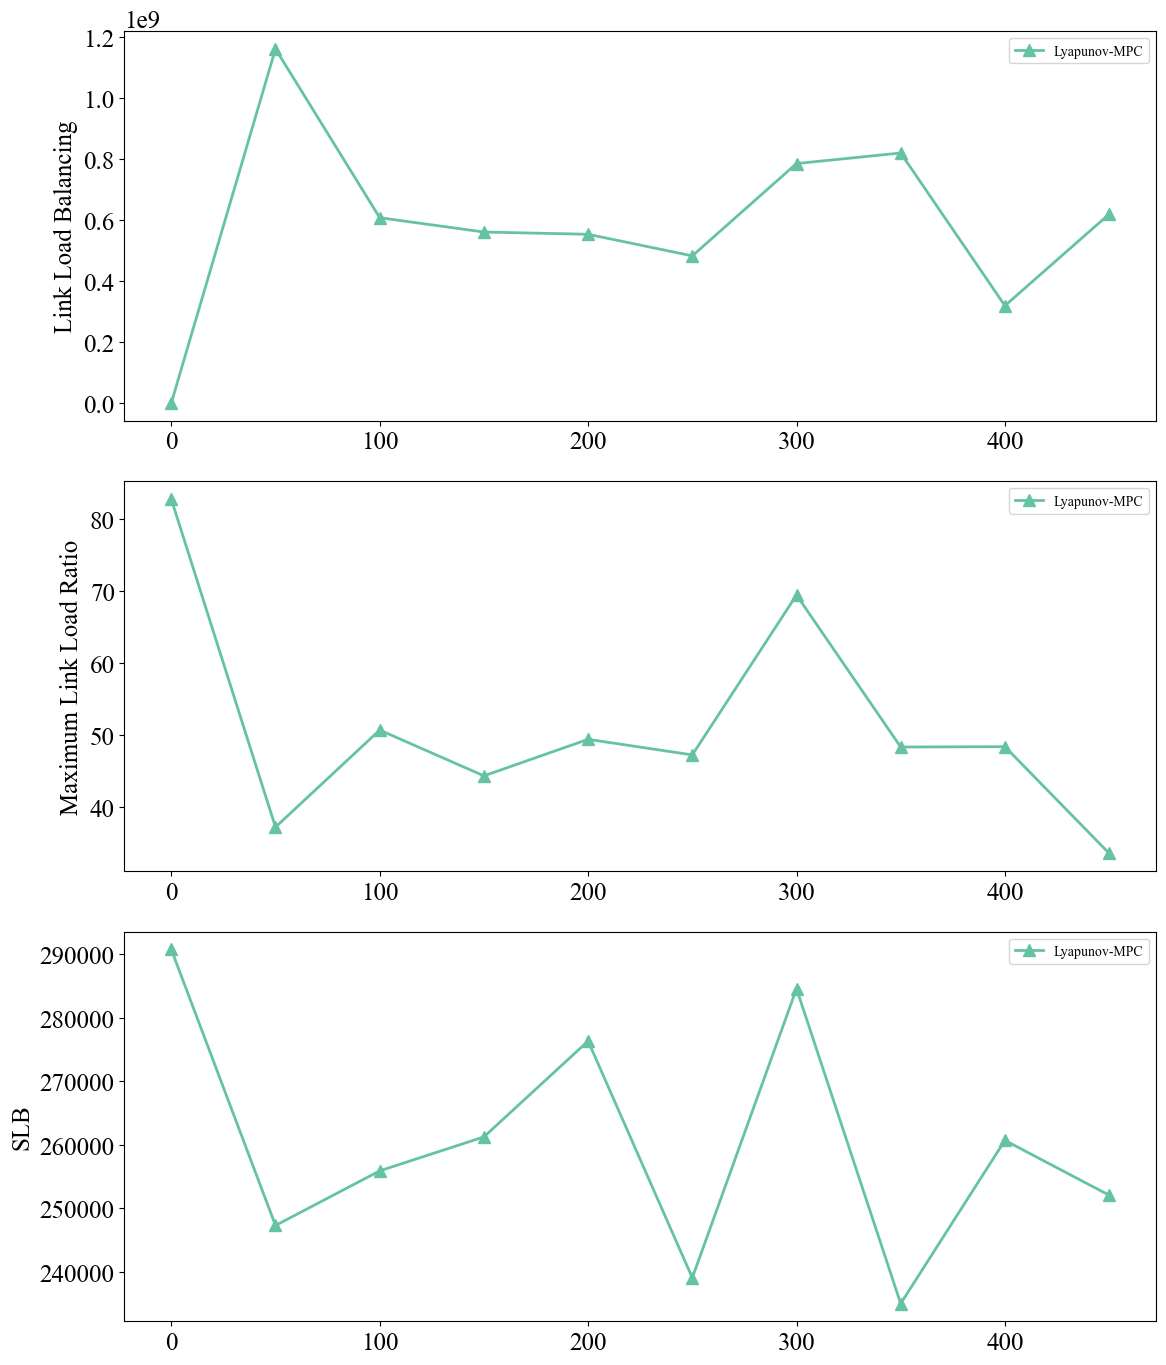

In [3]:
lyap_MPC = json.load(
    open(r"lyap_MPC_record_V_test.json", "r")
)

# * obtain data
last_task_num = []
V_list = [i for i in range(0, 500, 50)]
len_per_test = 20
mean_value_V = []  # lyap_MPC, nearest_gnd, nearest, rand

for idx, item in enumerate(lyap_MPC):
    if (idx % len_per_test) == 0:
        mean_value_V.append([{}])
        # * offload cost
        mean_value_V[-1][0]["offload_cost"] = item["offload_cost"]

        # * LLR
        mean_value_V[-1][0]["link_load_ratio"] = item["link_load_ratio"]

        # * SPR
        mean_value_V[-1][0]["sat_pload_ratio"] = item["sat_pload_ratio"]

        # * MLLR
        mean_value_V[-1][0]["max_link_load_ratio"] = item["max_link_load_ratio"]

        # * MSP
        mean_value_V[-1][0]["max_sat_pload"] = item["max_sat_pload"]

    else:
        # * offload cost
        mean_value_V[-1][0]["offload_cost"] += item["offload_cost"]

        # * LLR
        mean_value_V[-1][0]["link_load_ratio"] += item["link_load_ratio"]

        # * SPR
        mean_value_V[-1][0]["sat_pload_ratio"] += item["sat_pload_ratio"]

        # * MLLR
        mean_value_V[-1][0]["max_link_load_ratio"] += item["max_link_load_ratio"]

        # * MSP
        mean_value_V[-1][0]["max_sat_pload"] += item["max_sat_pload"]

# for idx, length in enumerate(len_list):
for idx in range(len(mean_value_V)):
    mean_value_V[idx][0]["offload_cost"] /= len_per_test
    mean_value_V[idx][0]["link_load_ratio"] /= len_per_test
    mean_value_V[idx][0]["sat_pload_ratio"] /= len_per_test
    mean_value_V[idx][0]["max_link_load_ratio"] /= len_per_test
    mean_value_V[idx][0]["max_sat_pload"] /= len_per_test

print(f"mean_value_V {mean_value_V}")

# * draw 4 subplots, with x-axis: V_list, y-axis: 4 keys in mean_value_V
new_metric_list = ["Offload Cost", "Satellite Physical Load Ratio", "MSPL"]
fig, axs = plt.subplots(3, 1, figsize=(12, 14))
for idx, key in enumerate(
    ["offload_cost", "sat_pload_ratio", "max_sat_pload"]
):
    y1 = [item[0][key] for item in mean_value_V]

    ax = axs[idx % 3]
    ax.plot(V_list, y1, label="Lyapunov-MPC", marker="^", markersize=marker_size)

    # ax.set_xlabel(f"({subplot_name[idx]})")
    # ax.set_xlabel('Walker Delta Constellation Size')
    ax.set_ylabel(metric_list[idx])
    # ax.set_title(f'{key} vs const_size')
    ax.legend()

# fig.text(0.5, 0.01, "Walker Delta Constellation Size", ha="center")
plt.tight_layout()
fig.savefig("V.pdf", bbox_inches="tight")
plt.show()